In [4]:
# using linear regression to predict housing prices

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
# Generate synthetic house price dataset
np.random.seed(42)

house_size = np.random.randint(800, 4000, 100)
house_price = (house_size * 200) + 50000 + np.random.normal(0, 40000, 100)

df = pd.DataFrame({
    'Square_Footage': house_size,
    'Price': house_price
})

display(df.head())

,Square_Footage,Price
0,3974,799577.907813
1,1660,387377.155305
2,2094,492084.911789
3,1930,471509.938384
4,1895,464773.293204


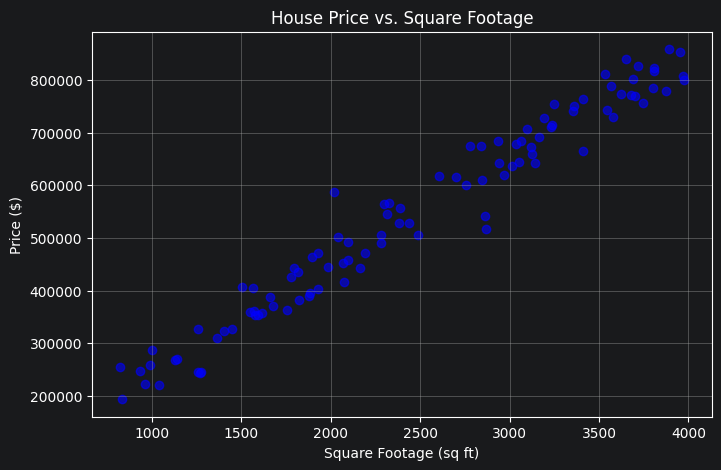

In [7]:
# Visualize the raw data
plt.figure(figsize=(8, 5))
plt.scatter(df['Square_Footage'], df['Price'], color='blue', alpha=0.6)
plt.title('House Price vs. Square Footage')
plt.xlabel('Square Footage (sq ft)')
plt.ylabel('Price ($)')
plt.grid(True)
plt.show()

In [8]:
# Split data into training and testing sets
X = df[['Square_Footage']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} samples")
print(f"Testing data size: {X_test.shape[0]} samples")

Training data size: 80 samples
Testing data size: 20 samples


In [9]:
# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

m = model.coef_[0]
c = model.intercept_

print(f"Model trained successfully!")
print(f"Regression Line Equation: Price = {m:.2f} * (SqFt) + {c:.2f}")

Model trained successfully!
Regression Line Equation: Price = 204.38 * (SqFt) + 39580.04


In [10]:
# Evaluate the model performance
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared Score: {r2:.4f}")

--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): $35,316.98
Root Mean Squared Error (RMSE): $45,752.52
R-squared Score: 0.9490


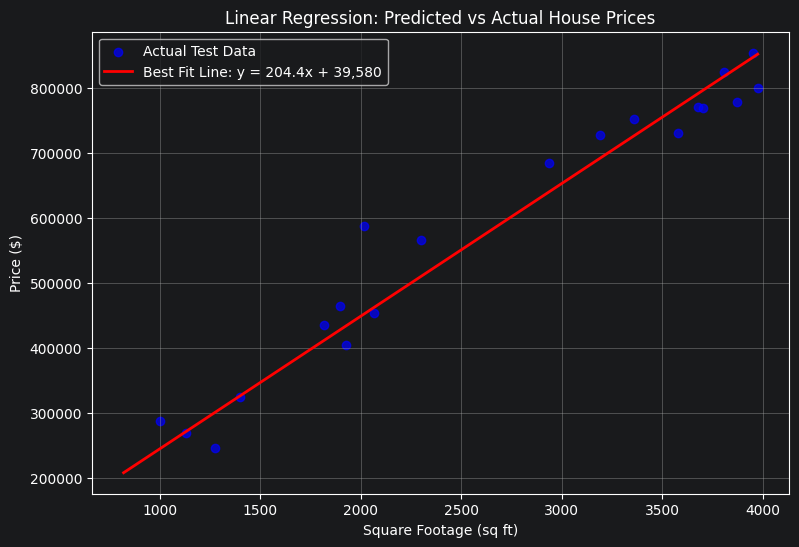

In [11]:
# Plot the final regression line
plt.figure(figsize=(9, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Test Data', alpha=0.7)

x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(pd.DataFrame(x_line, columns=['Square_Footage']))

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Best Fit Line: y = {m:.1f}x + {c:,.0f}')

plt.title('Linear Regression: Predicted vs Actual House Prices')
plt.xlabel('Square Footage (sq ft)')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()